# Algoritmo Genético Simple

Maximizar la función: $f(x, y) = 21.5 + x \cdot \sin(4\pi x) + y \cdot \sin(20\pi y)$
- **X** [-3.0, 12.1]
- **Y** [4.1, 5.8]
- Precisión: 4 decimales

## 1. Librerías

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## 2. Parámetros del Algoritmo Genético

In [3]:
# Valores de las variables
Nind = 100 # Número de individuos
Lind = 33 # Longitud del cromosoma (18 bits para X + 15 bits para Y)
Pc = 0.9 # Probabilidad de cruza
Pm = 0.01 #Probabilidad de mutación
Maxgen = 1000 # Número máximo de generaciones
Nvar = 2 # Número de variables
rango  = np.array([[-3.0, 4.1], [12.1, 5.8]])

## 3. Funciones del Algoritmo Genético

In [8]:
def creapob(Nind, Lind):
    #Crea una población inicial aleatoria de cromosomas binarios
    return np.random.randint(0, 2, size=(Nind, Lind))


def decodifica(genotipo, rango):
    """
    Decodifica la población binaria al dominio real del problema.
    Fórmula: xi = li + decimal(bits) * (ls - li) / (2^Lvar - 1)
    """
    Nvar = rango.shape[1]
    Nind, Lind = genotipo.shape
    Lvar  = Lind // Nvar
    potencias = 2 ** np.arange(Lvar)
    
    fenotipo  = np.zeros((Nind, Nvar))

    for i in range(Nind):
        for j in range(Nvar):
            fenotipo[i, j] = np.sum(potencias * genotipo[i, (j * Lvar):(j * Lvar + Lvar)])

    for i in range(Nvar):
        fenotipo[:, i] = (rango[0, i] + ((rango[1, i] - rango[0, i]) / (2 ** Lvar - 1))* fenotipo[:, i])

    return fenotipo


def objfun(fenotipo):
    #Evalúa la función objetivo para cada individuo de la población
    Nind, Nvar = fenotipo.shape
    objv = np.zeros((Nind, 1))
    
    for i in range(Nind):
        objv[i,0] = 21.5 + fenotipo[i,0] * np.sin(4 * np.pi * fenotipo[i,0]) + fenotipo[i,1] * np.sin(20 * np.pi * fenotipo[i,1])
    return objv


def rankeo(objv, direccion):
    """
    Asigna aptitud basada en rankeo lineal.
    direccion=1 -> maximizar | direccion=-1 -> minimizar
    """
    SP   = 2
    Nind, Nobj = objv.shape
    aptitud  = np.zeros((Nind, 1))

    if direccion == 1:
        nuevo_objv = np.sort(objv, axis=0)
    else:
        nuevo_objv = np.sort(-1 * objv, axis=0)

    apt = 2 - SP + 2 * (SP - 1) * (np.arange(Nind) / (Nind - 1))
    posori = np.argsort(nuevo_objv, axis=0)
    
    aptitud[posori, 0] = apt.reshape(-1, 1)

    return aptitud


def ruleta(genotipo, fenotipo, aptitud):
    #Selección proporcional (ruleta) — devuelve nueva generación seleccionada
    Nind, aux = aptitud.shape
    total = np.sum(aptitud)
    probabilidad = aptitud / total
    acumulada = np.cumsum(probabilidad)
    idx = np.zeros(Nind, dtype=int)

    for i in range(Nind):
        selecciona = np.random.rand()
        aux = np.where(acumulada >= selecciona)[0]
        idx[i] = aux[0]

    nuevo_gen = genotipo[idx.flatten(), :]

    return nuevo_gen


def xunpunto(nuevo_gen, Pc):
    #Cruza de un punto con probabilidad Pc
    Nind, Lind = nuevo_gen.shape
    aux_gen = np.zeros((Nind, Lind))
    par = Nind % 2

    for i in range(0, Nind - 1, 2):
        cruza = np.random.rand()
        if cruza <= Pc:
            corte = np.random.randint(0, Lind -1)
            aux_gen[i, :] = np.concatenate((nuevo_gen[i, :corte], nuevo_gen[i+1, corte:]))
            aux_gen[i+1, :] = np.concatenate((nuevo_gen[i+1, :corte], nuevo_gen[i, corte:]))
        else:
            aux_gen[i, :] = nuevo_gen[i, :]
            aux_gen[i+1, :] = nuevo_gen[i+1, :]

    if par == 1:
        aux_gen[Nind - 1, :] = nuevo_gen[Nind - 1, :]

    nuevo_gen = aux_gen
    
    return nuevo_gen


def muta(nuevo_gen, Pm):
    #Mutación aleatoria bit a bit con probabilidad Pm
    Nind, Lind = nuevo_gen.shape
    valores = np.random.rand(Nind, Lind)
    muta = valores <= Pm
    nuevo_gen  = np.logical_xor(nuevo_gen, muta)
    
    return nuevo_gen


## 4. Ejecución del Algoritmo Genético

In [9]:
np.random.seed(42) 

# Población inicial 
genotipo = creapob(Nind, Lind)
fenotipo = decodifica(genotipo, rango)
objv = objfun(fenotipo) # evaluación de la función

# Almacenamiento de resultados
Mejor = np.full((Maxgen, 1), np.nan) #Referencia al mejor valor óptimo encontrado de la función objetivo
Mejor_cromosoma  = np.zeros((Maxgen, Lind)) # Mejor valor (nodo) encontrado por cada generación

idx_initial = np.argmax(objv)
Mejor[0] = objv[idx_initial]
Mejor_cromosoma[0, :] = genotipo[idx_initial, :]

# --- Ciclo evolutivo ---
generaciones = 1
while generaciones < Maxgen: #Número de generaciones predefinidas

    # Aptitud
    aptitud = rankeo(objv, 1) #cada generación se establece el fitness para cada solución encontrada

    # Selección
    nuevo_gen = ruleta(genotipo, fenotipo, aptitud)

    # Cruza
    nuevo_gen = xunpunto(nuevo_gen, Pc)

    # Mutación
    nuevo_gen = muta(nuevo_gen, Pm)

    # Decodificar y evaluar nueva población
    nuevo_feno = decodifica(nuevo_gen, rango)
    nuevo_objv = objfun(nuevo_feno)

    # Reemplazar población
    genotipo = nuevo_gen
    fenotipo = nuevo_feno
    objv     = nuevo_objv

    # Guardar el mejor de esta generación
    idx = np.argmax(objv)
    Mejor[generaciones] = objv[idx]
    Mejor_cromosoma[generaciones, :]  = genotipo[idx, :]

    generaciones += 1

# --- Resultado final ---
mejor_gen  = np.nanargmax(Mejor)
mejor_val  = Mejor[mejor_gen, 0]
mejor_crom = Mejor_cromosoma[mejor_gen, :]
mejor_feno = decodifica(mejor_crom.reshape(1, -1), rango)

print('='*50)
print(f'  Mejor generación : {mejor_gen}')
print(f'  Mejor f(x,y)     : {mejor_val:.6f}')
print(f'  x óptimo         : {mejor_feno[0, 0]:.6f}')
print(f'  y óptimo         : {mejor_feno[0, 1]:.6f}')
print('='*50)

  Mejor generación : 191
  Mejor f(x,y)     : 38.598820
  x óptimo         : 12.100000
  y óptimo         : 5.623294


## 5. Gráfica 3D de la Función Objetivo (Programación Estructurada)

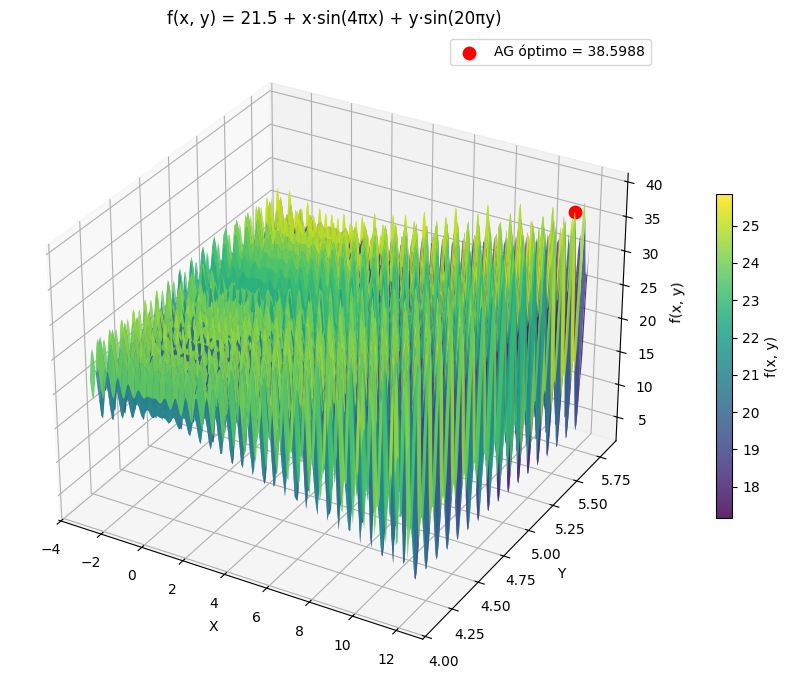


Máximo por fuerza bruta : f = 38.690830  en x=12.1000, y=5.7231
Máximo encontrado por AG: f = 38.598820  en x=12.1000, y=5.6233


In [12]:
def f(x, y):
    return 21.5 + x * np.sin(4 * np.pi * x) + y * np.sin(20 * np.pi * y)

# Generar datos para x y y
x_lin = np.linspace(-3, 12.1, 200)
y_lin = np.linspace(4.1, 5.8, 200)
X, Y = np.meshgrid(x_lin, y_lin)
Z = f(X, Y)

#Crear la gráfica en 3D
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.85)

# Marcar el punto óptimo encontrado por el AG
ax.scatter(
    mejor_feno[0, 0], mejor_feno[0, 1], mejor_val,
    color='red', s=80, zorder=5, label=f'AG óptimo = {mejor_val:.4f}'
)

fig.colorbar(surf, ax=ax, shrink=0.5, label='f(x, y)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(x, y)')
ax.set_title('f(x, y) = 21.5 + x·sin(4πx) + y·sin(20πy)')
ax.legend()
plt.tight_layout()
plt.show()

#  Máximo global por fuerza bruta 
max_bruto = np.max(Z)
idx_max   = np.unravel_index(np.argmax(Z), Z.shape)
print(f'\nMáximo por fuerza bruta : f = {max_bruto:.6f}  '
      f'en x={x_lin[idx_max[1]]:.4f}, y={y_lin[idx_max[0]]:.4f}')
print(f'Máximo encontrado por AG: f = {mejor_val:.6f}  '
      f'en x={mejor_feno[0,0]:.4f}, y={mejor_feno[0,1]:.4f}')